In [ ]:
import csv
import pandas as pd

In [ ]:
params = {
    'fileLocation': 'database\\winemag-data-130k-v2_clean.csv',
}

## Adatok előfeldolgozása

In [ ]:
df = csv.reader(open(params['fileLocation'], 'r', encoding='utf-8'))
columns = next(df)
columns[0] = 'id'  # Az első oszlop neve 'id' legyen
df = pd.DataFrame(df, columns=columns)

print(df.shape)
display(df.head())

(129971, 7)


,id,country,description,points,province,region_1,region_2
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",87,Sicily & Sardinia,Etna,
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",87,Douro,,
2,2,US,"Tart and snappy, the flavors of lime flesh and...",87,Oregon,Willamette Valley,Willamette Valley
3,3,US,"Pineapple rind, lemon pith and orange blossom ...",87,Michigan,Lake Michigan Shore,
4,4,US,"Much like the regular bottling from 2012, this...",87,Oregon,Willamette Valley,Willamette Valley


In [ ]:
df_categorized = df[['id', 'country', 'description', 'points', 'province', 'region_1', 'region_2']].copy()

# Konvertálás int-re
df_categorized['points'] = df_categorized['points'].astype(int)

# Min-Max skálázás (0-1 közé)
# Képlet: (x - min) / (max - min)
p_min = df_categorized['points'].min()
p_max = df_categorized['points'].max()
df_categorized['points_scaled'] = (df_categorized['points'] - p_min) / (p_max - p_min)

df_categorized['group'] = pd.qcut(df_categorized['points'],
                                 q=4,
                                 labels=['poor', 'below_avg', 'above_avg', 'excellent'])

# display(df_categorized['group'].value_counts())
display(df_categorized.head(5))

,id,country,description,points,province,region_1,region_2,group
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",87,Sicily & Sardinia,Etna,,below_avg
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",87,Douro,,,below_avg
2,2,US,"Tart and snappy, the flavors of lime flesh and...",87,Oregon,Willamette Valley,Willamette Valley,below_avg
3,3,US,"Pineapple rind, lemon pith and orange blossom ...",87,Michigan,Lake Michigan Shore,,below_avg
4,4,US,"Much like the regular bottling from 2012, this...",87,Oregon,Willamette Valley,Willamette Valley,below_avg


## Adatok megismerése

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Alapvető statisztikák
print(f"Adatbázis mérete: {df.shape}")
print("\nHiányzó adatok száma:")
print(df.isnull().sum())

Adatbázis mérete: (129971, 7)

Hiányzó adatok száma:
id             0
country        0
description    0
points         0
province       0
region_1       0
region_2       0
dtype: int64


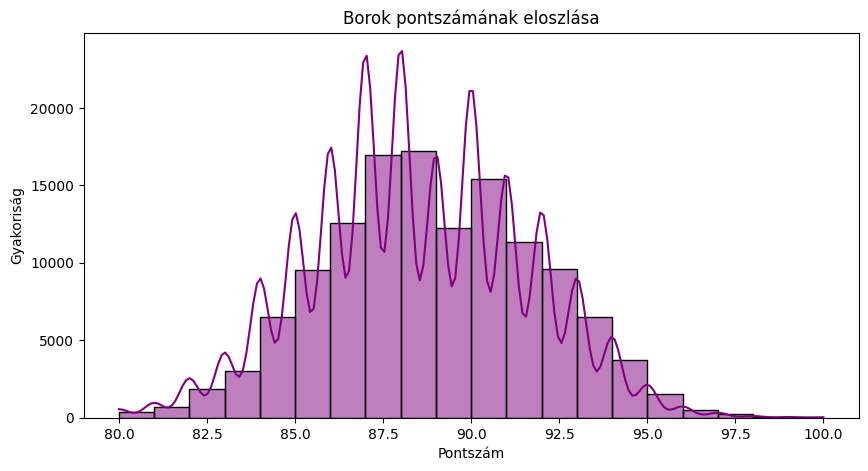

Átlagos pontszám: 88.45
Leggyakoribb pontszám: 88


In [ ]:
# 2. Pontszámok eloszlása
plt.figure(figsize=(10, 5))
# Mivel a csv olvasáskor minden string lehet, konvertáljuk int-re
sns.histplot(df['points'].astype(int), bins=20, kde=True, color='purple')
plt.title('Borok pontszámának eloszlása')
plt.xlabel('Pontszám')
plt.ylabel('Gyakoriság')
plt.show()

print(f"Átlagos pontszám: {df['points'].astype(int).mean():.2f}")
print(f"Leggyakoribb pontszám: {df['points'].astype(int).mode()[0]}")

Összesen 44 különböző ország található.


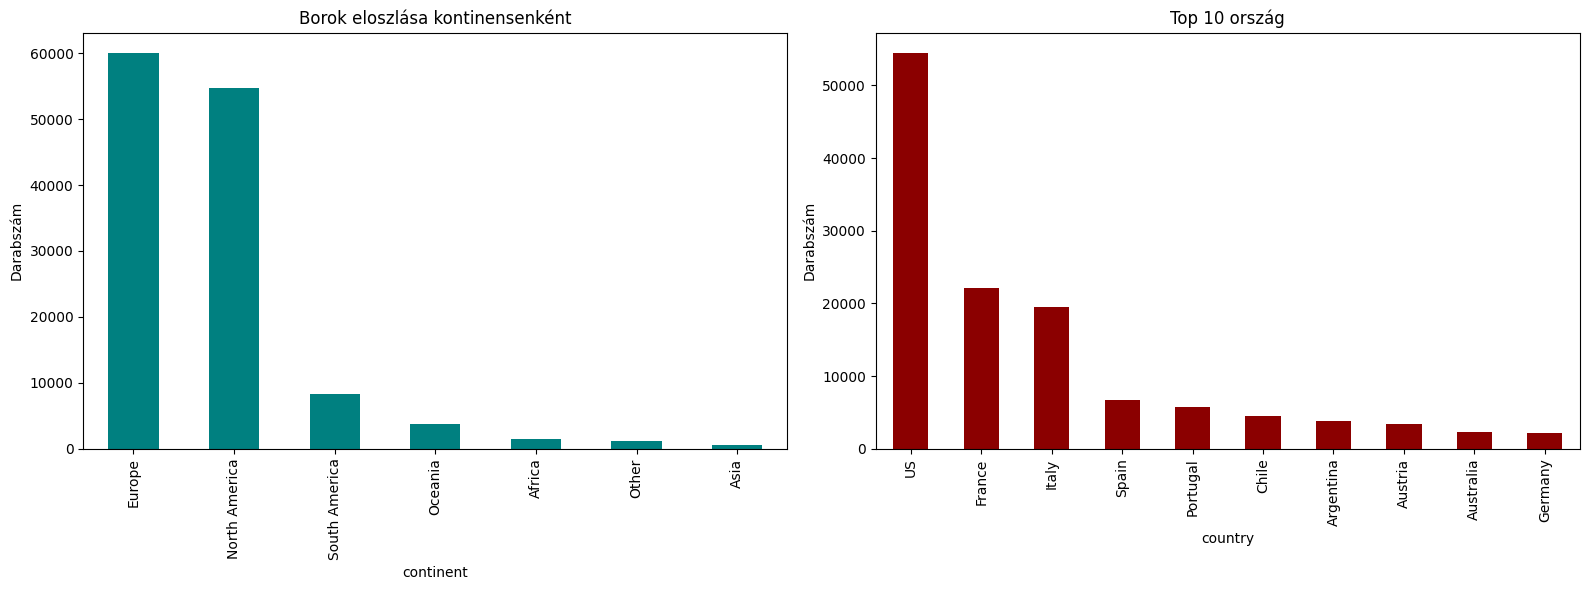

In [ ]:
# 3. Országok és Kontinensek
# Egyszerű kontinens leképezés a főbb bortermelő országokra
continent_map = {
    'US': 'North America', 'France': 'Europe', 'Italy': 'Europe', 'Spain': 'Europe', 
    'Portugal': 'Europe', 'Chile': 'South America', 'Argentina': 'South America', 
    'Australia': 'Oceania', 'Austria': 'Europe', 'Germany': 'Europe', 
    'New Zealand': 'Oceania', 'South Africa': 'Africa', 'Israel': 'Asia', 
    'Greece': 'Europe', 'Canada': 'North America', 'Hungary': 'Europe'
}

# Új oszlop a vizualizációhoz (ahol nincs megadva, ott 'Other')
df['continent'] = df['country'].map(continent_map).fillna('Other')

print(f"Összesen {df['country'].nunique()} különböző ország található.")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Kontinensek
df['continent'].value_counts().plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Borok eloszlása kontinensenként')
axes[0].set_ylabel('Darabszám')

# Top 10 Ország
df['country'].value_counts().head(10).plot(kind='bar', ax=axes[1], color='darkred')
axes[1].set_title('Top 10 ország')
axes[1].set_ylabel('Darabszám')

plt.tight_layout()
plt.show()

Különböző tartományok (Province) száma: 426


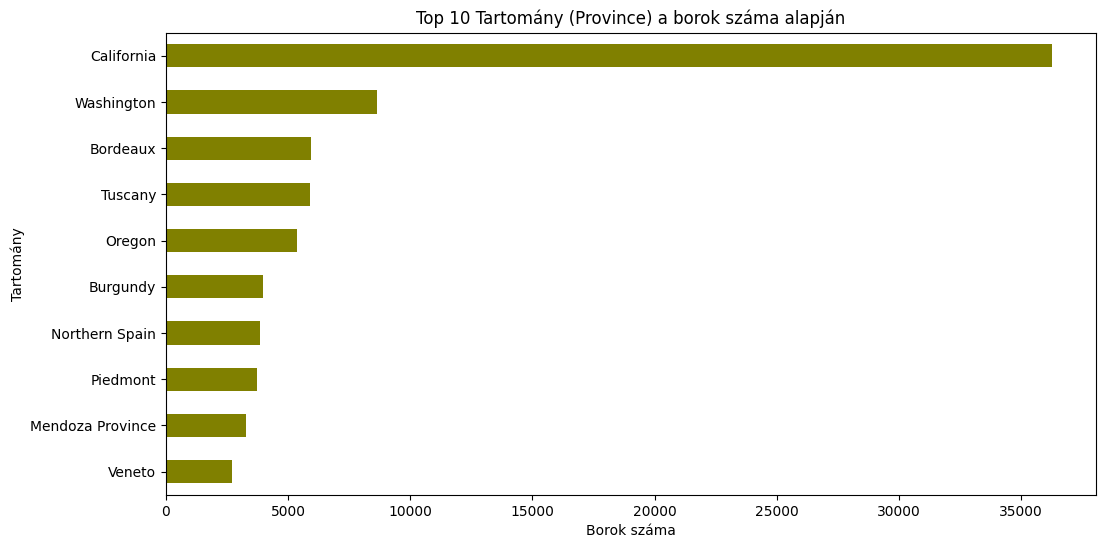

In [ ]:
# 4. Régiók és Tartományok eloszlása
print(f"Különböző tartományok (Province) száma: {df['province'].nunique()}")

# Top 10 Tartomány
plt.figure(figsize=(12, 6))
df['province'].value_counts().head(10).plot(kind='barh', color='olive')
plt.title('Top 10 Tartomány (Province) a borok száma alapján')
plt.xlabel('Borok száma')
plt.ylabel('Tartomány')
plt.gca().invert_yaxis()
plt.show()

Összefüggés keresése

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Beállítások a szebb grafikonokért
sns.set_theme(style="whitegrid")

# Biztosítjuk, hogy a points oszlop numerikus legyen a vizualizációhoz
df_categorized['points'] = df_categorized['points'].astype(int)

# 1. Országok szerinti átlagos pontszám vizsgálata
# Csak azok az országok, ahol van elég adat (pl. több  mint 100 értékelés), hogy elkerüljük a torzítást
country_counts = df_categorized['country'].value_counts()
valid_countries = country_counts[country_counts > 100].index
df_filtered_country = df_categorized[df_categorized['country'].isin(valid_countries)]

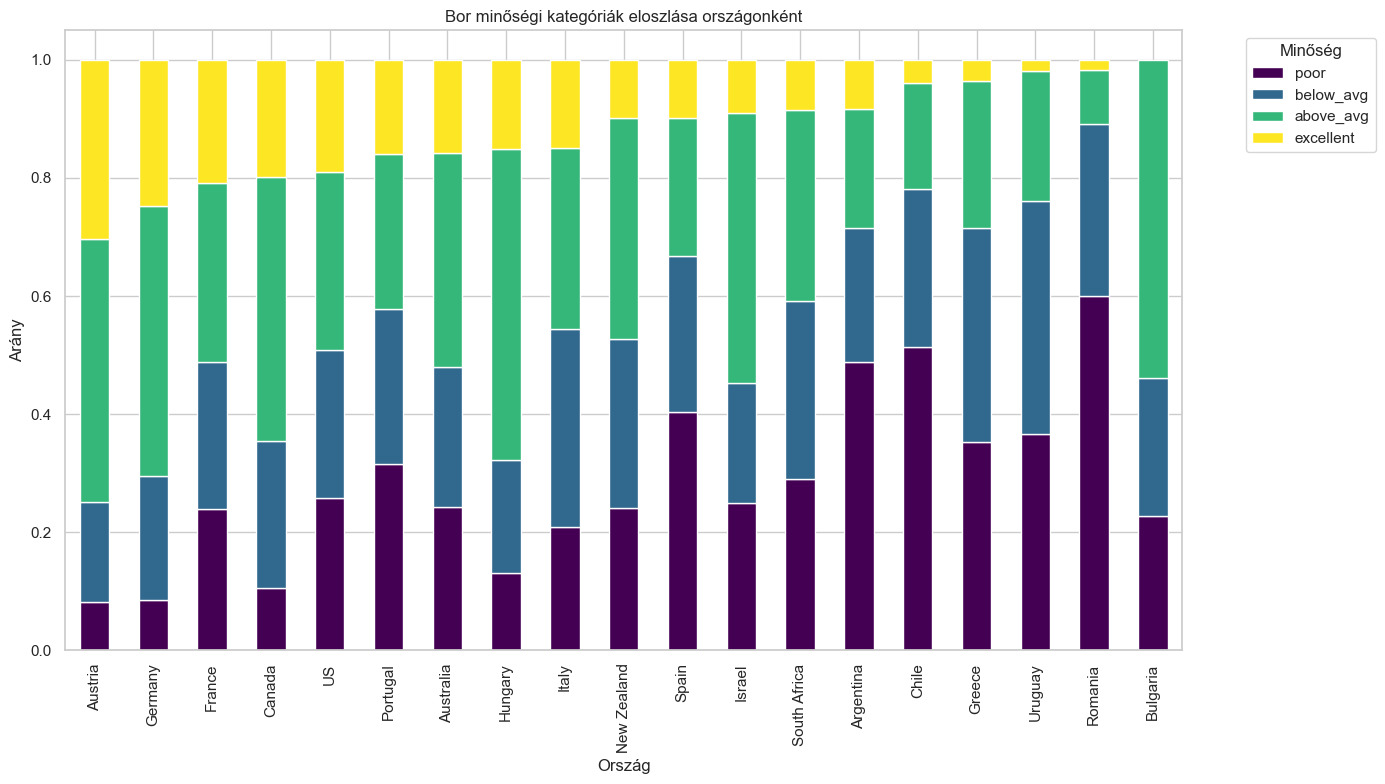

In [ ]:
# 2. Minőségi kategóriák eloszlása országonként
# Ez megmutatja, hogy egy adott országból származó bor mekkora eséllyel esik egy bizonyos minőségi kategóriába

# Kereszttábla készítése és normalizálása (százalékos eloszlás)
ct = pd.crosstab(df_filtered_country['country'], df_filtered_country['group'], normalize='index')

# Rendezés: azon országok kerüljenek előre, ahol a legnagyobb az "excellent" borok aránya
ct = ct.reindex(ct.sort_values(by='excellent', ascending=False).index)

# Stacked bar chart
ct.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='viridis')
plt.title('Bor minőségi kategóriák eloszlása országonként')
plt.ylabel('Arány')
plt.xlabel('Ország')
plt.legend(title='Minőség', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

C:\Users\2314l\AppData\Local\Temp\ipykernel_13464\3113478984.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_avg_points.index, y=country_avg_points.values, palette="coolwarm")


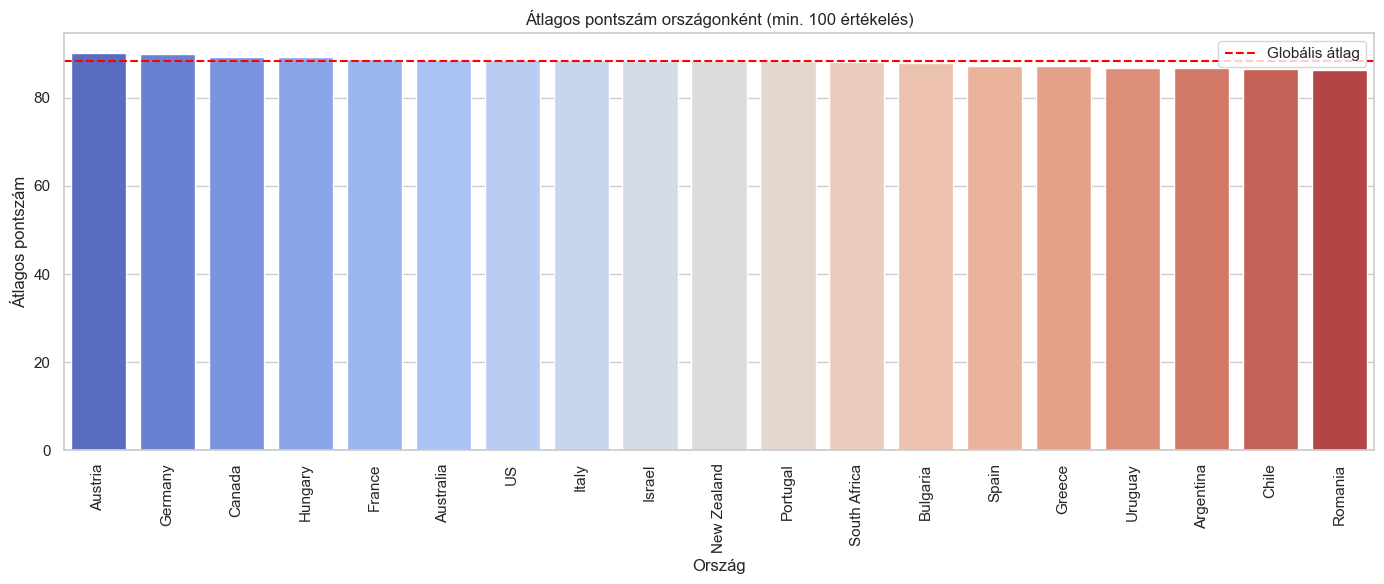

Top 5 ország átlagos pontszám szerint:
country
Austria    90.101345
Germany    89.851732
Canada     89.369650
Hungary    89.191781
France     88.845109
Name: points, dtype: float64

Bottom 5 ország átlagos pontszám szerint:
country
Greece       87.283262
Uruguay      86.752294
Argentina    86.710263
Chile        86.493515
Romania      86.400000
Name: points, dtype: float64


In [ ]:
# 3. Átlagos pontszám országonként - Oszlopdiagram a jobb vizualizációért
# Ez a grafikon megmutatja a konkrét átlagokat is

country_avg_points = df_filtered_country.groupby('country')['points'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(x=country_avg_points.index, y=country_avg_points.values, palette="coolwarm")
plt.xticks(rotation=90)
plt.title('Átlagos pontszám országonként (min. 100 értékelés)')
plt.ylabel('Átlagos pontszám')
plt.xlabel('Ország')
plt.axhline(y=df_filtered_country['points'].mean(), color='red', linestyle='--', label='Globális átlag')
plt.legend()
plt.tight_layout()
plt.show()

# Top 5 és Bottom 5 ország átlagpontszáma
print("Top 5 ország átlagos pontszám szerint:")
print(country_avg_points.head())
print("\nBottom 5 ország átlagos pontszám szerint:")
print(country_avg_points.tail())

C:\Users\2314l\AppData\Local\Temp\ipykernel_13464\791055699.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='keyword', y='avg_points', data=df_keywords, palette="RdYlGn")


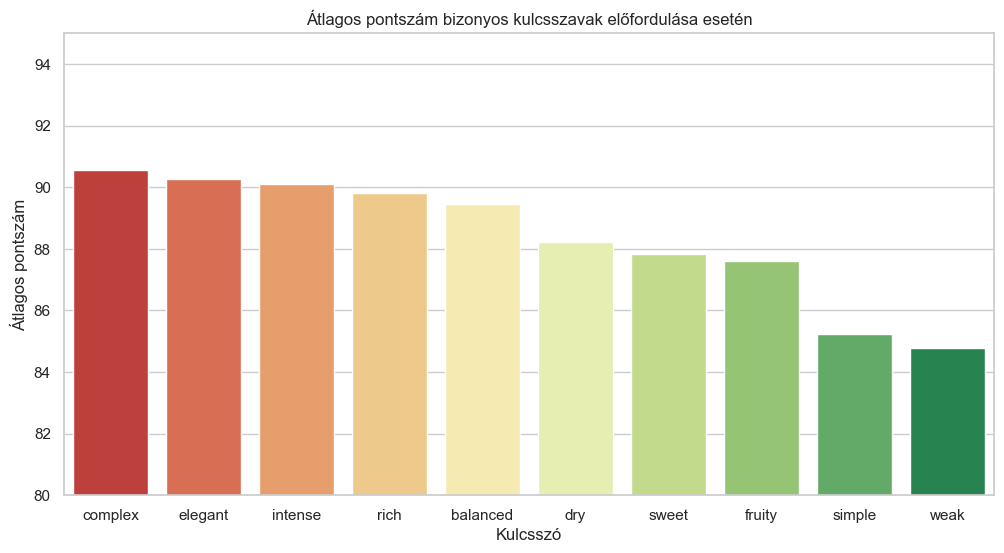

,keyword,avg_points,count
1,complex,90.547708,8269
2,elegant,90.268567,5682
9,intense,90.090947,4805
3,rich,89.803523,22710
7,balanced,89.445118,8582
5,dry,88.219920,18484
6,sweet,87.840242,15730
4,fruity,87.600529,9455
0,simple,85.228661,3831
8,weak,84.781690,142


In [ ]:
# 5. Kulcsszavak keresése a leírásban (Szövegbányászat alapok)
# Mivel a 'description' mező szöveges, keressünk benne olyan szavakat, amik utalhatnak a minőségre.

keywords = ['simple', 'complex', 'elegant', 'rich', 'fruity', 'dry', 'sweet', 'balanced', 'weak', 'intense']
keyword_stats = []

for word in keywords:
    # Megnézzük azokat a sorokat, ahol szerepel a szó (kis/nagybetű nem számít)
    mask = df_categorized['description'].str.contains(word, case=False, na=False)
    if mask.sum() > 0:
        avg_score = df_categorized.loc[mask, 'points'].astype(int).mean()
        count = mask.sum()
        keyword_stats.append({'keyword': word, 'avg_points': avg_score, 'count': count})

df_keywords = pd.DataFrame(keyword_stats).sort_values(by='avg_points', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='keyword', y='avg_points', data=df_keywords, palette="RdYlGn")
plt.ylim(80, 95) # A skála szűkítése a különbségek kiemelésére
plt.title('Átlagos pontszám bizonyos kulcsszavak előfordulása esetén')
plt.ylabel('Átlagos pontszám')
plt.xlabel('Kulcsszó')
plt.show()

display(df_keywords)

C:\Users\2314l\AppData\Local\Temp\ipykernel_13464\1537388153.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='points', y='desc_length', data=df_description, palette="Blues")


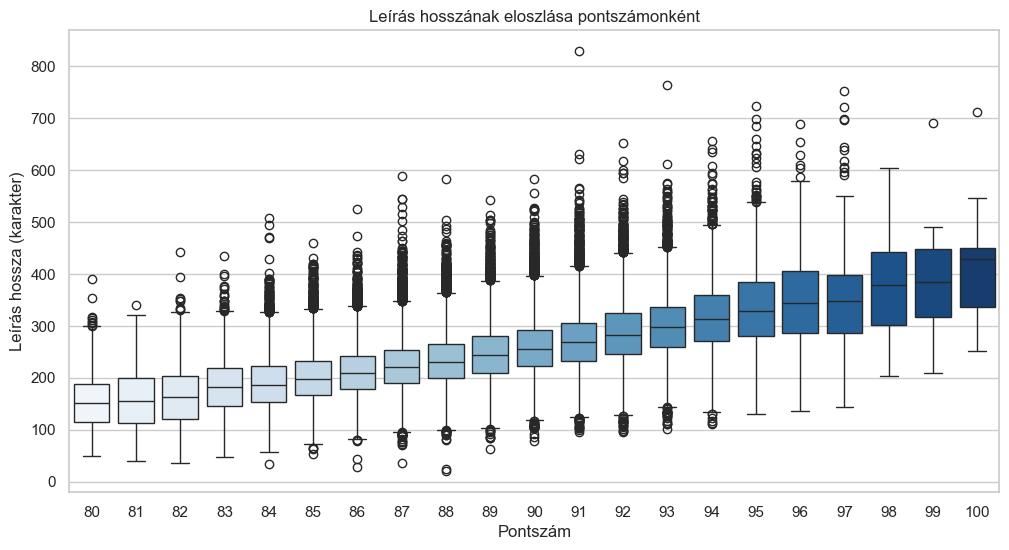

Korreláció a leírás hossza és a pontszám között: 0.56


In [ ]:
# 4. Leírás hossza és a Pontszám kapcsolata
# Hipotézis: A kritikusok többet írnak azokról a borokról, amelyeket jobbnak találnak.

# Hossz kiszámítása
df_categorized['desc_length'] = df_categorized['description'].str.len()

plt.figure(figsize=(12, 6))
# Boxplot a pontszámok és a hossz összefüggésére
sns.boxplot(x='points', y='desc_length', data=df_categorized, palette="Blues")
plt.title('Leírás hosszának eloszlása pontszámonként')
plt.xlabel('Pontszám')
plt.ylabel('Leírás hossza (karakter)')
plt.show()

# Korreláció
corr_len = df_categorized['desc_length'].corr(df_categorized['points'].astype(int))
print(f"Korreláció a leírás hossza és a pontszám között: {corr_len:.2f}")

C:\Users\2314l\AppData\Local\Temp\ipykernel_13464\895793616.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='positive_words', y='points', data=df_description[df_description['positive_words'] <= 5],
C:\Users\2314l\AppData\Local\Temp\ipykernel_13464\895793616.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='sentiment_score', y='points',


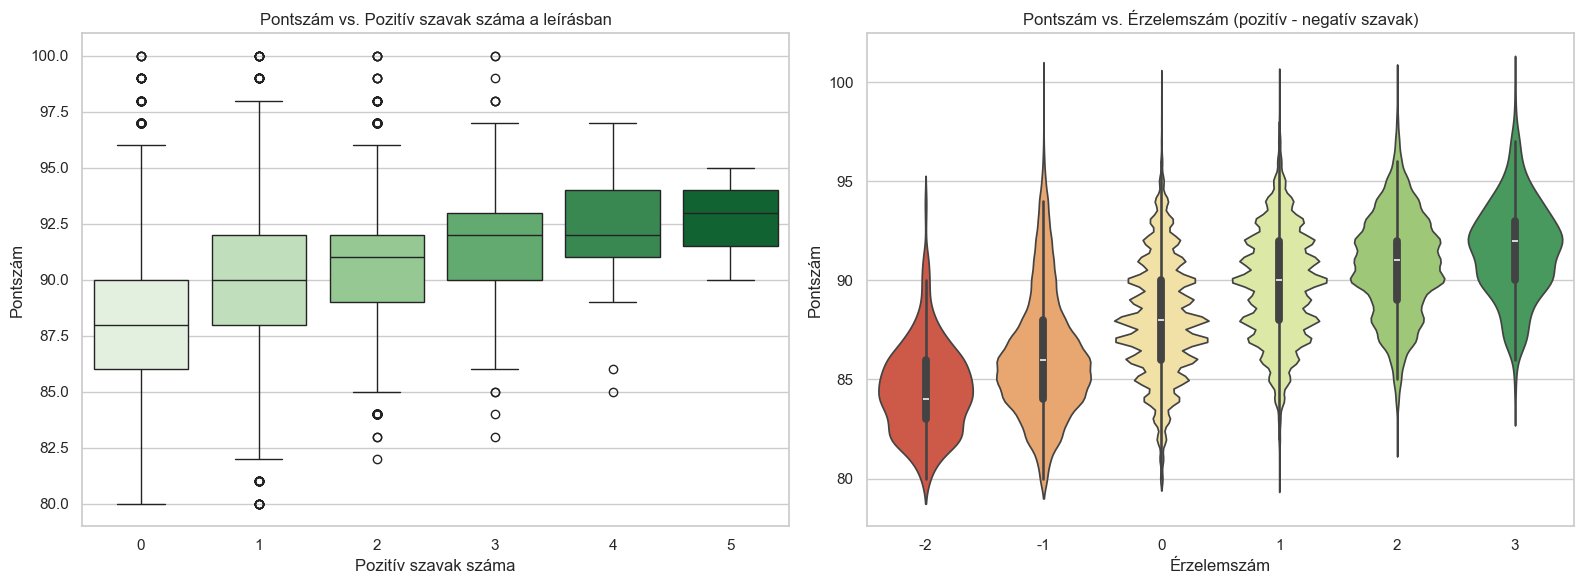

Korreláció pozitív szavak és pontszám között: 0.321
Korreláció érzelemszám és pontszám között: 0.363


In [ ]:
# 10. Leírásban szereplő pozitív és negatív szavak hatása
# Pontosabb szövegbányászat - több minőségjelző szó

positive_words = ['excellent', 'exceptional', 'outstanding', 'superb', 'remarkable', 
                  'complex', 'elegant', 'rich', 'balanced', 'harmonious', 'refined']
negative_words = ['simple', 'basic', 'ordinary', 'weak', 'thin', 'harsh', 
                  'flat', 'dull', 'coarse', 'unbalanced']

def count_keywords(text, word_list):
    """Megszámolja, hány kulcsszó szerepel a szövegben"""
    if pd.isna(text):
        return 0
    text_lower = text.lower()
    return sum(1 for word in word_list if word in text_lower)

df_categorized['positive_words'] = df_categorized['description'].apply(lambda x: count_keywords(x, positive_words))
df_categorized['negative_words'] = df_categorized['description'].apply(lambda x: count_keywords(x, negative_words))
df_categorized['sentiment_score'] = df_categorized['positive_words'] - df_categorized['negative_words']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pozitív szavak vs pontszám
sns.boxplot(x='positive_words', y='points', data=df_categorized[df_categorized['positive_words'] <= 5], 
            ax=axes[0], palette="Greens")
axes[0].set_title('Pontszám vs. Pozitív szavak száma a leírásban')
axes[0].set_xlabel('Pozitív szavak száma')
axes[0].set_ylabel('Pontszám')

# Sentiment score (pozitív - negatív) vs pontszám
sns.violinplot(x='sentiment_score', y='points', 
               data=df_categorized[(df_categorized['sentiment_score'] >= -2) & (df_categorized['sentiment_score'] <= 3)],
               ax=axes[1], palette="RdYlGn")
axes[1].set_title('Pontszám vs. Érzelemszám (pozitív - negatív szavak)')
axes[1].set_xlabel('Érzelemszám')
axes[1].set_ylabel('Pontszám')

plt.tight_layout()
plt.show()

# Korreláció
print(f"Korreláció pozitív szavak és pontszám között: {df_categorized['positive_words'].corr(df_categorized['points']):.3f}")
print(f"Korreláció érzelemszám és pontszám között: {df_categorized['sentiment_score'].corr(df_categorized['points']):.3f}")

## Összegzés és következtetések

A fenti elemzések alapján a következő tényezők jelzik előre leginkább a bor minőségét:

1. **Földrajzi jellemzők**: Az ország és tartomány kombinációja erős predikciós erővel bír
2. **Szöveges jellemzők**: A leírás hossza és a pozitív minőségjelző szavak száma
3. **Aggregált információk**: Az adott ország/tartomány átlagos pontszáma

Ezek az összefüggések lehetővé teszik, hogy csak a terület és a leírás ismeretében megbecsüljük egy bor várható minőségét.

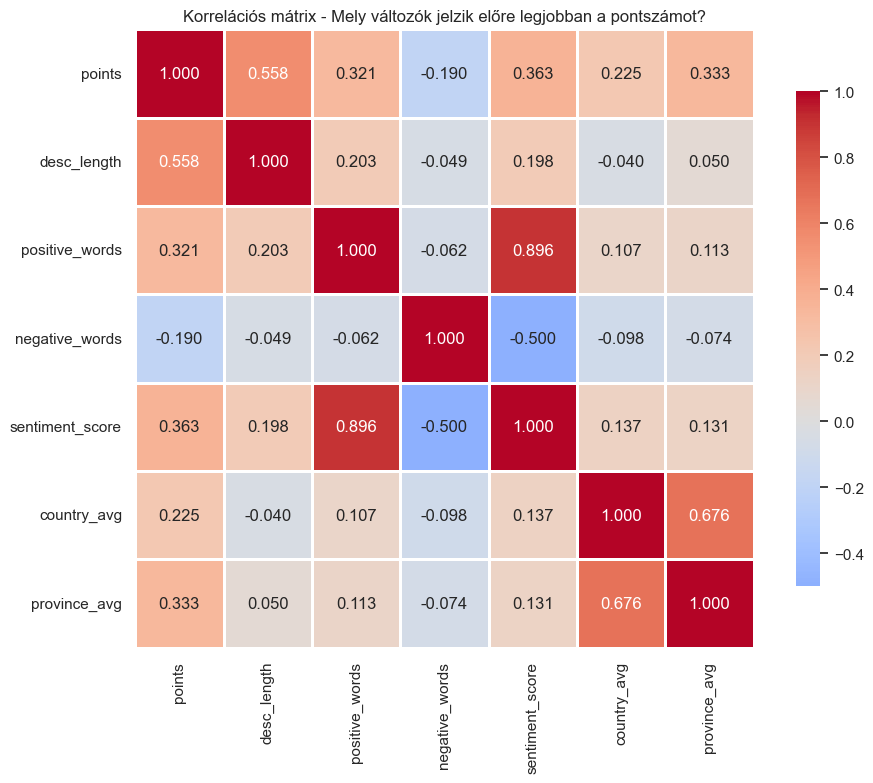


Korreláció a pontszámmal:
points             1.000000
desc_length        0.557760
sentiment_score    0.363414
province_avg       0.333382
positive_words     0.321226
country_avg        0.225251
negative_words    -0.189929
Name: points, dtype: float64


In [ ]:
# 11. Predikciós erő összefoglalása - Korrelációs mátrix
# Összegyűjtjük az összes numerikus változót és megvizsgáljuk a korrelációjukat a pontszámmal

# Létrehozunk néhány aggregált változót ország és tartomány szintjén
country_avg_map = df_categorized.groupby('country')['points'].transform('mean')
province_avg_map = df_categorized.groupby('province')['points'].transform('mean')

correlation_df = pd.DataFrame({
    'points': df_categorized['points'],
    'desc_length': df_categorized['desc_length'],
    'positive_words': df_categorized['positive_words'],
    'negative_words': df_categorized['negative_words'],
    'sentiment_score': df_categorized['sentiment_score'],
    'country_avg': country_avg_map,
    'province_avg': province_avg_map
})

# Korreláció számítás
corr_matrix = correlation_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Korrelációs mátrix - Mely változók jelzik előre legjobban a pontszámot?')
plt.tight_layout()
plt.show()

print("\nKorreláció a pontszámmal:")
print(corr_matrix['points'].sort_values(ascending=False))

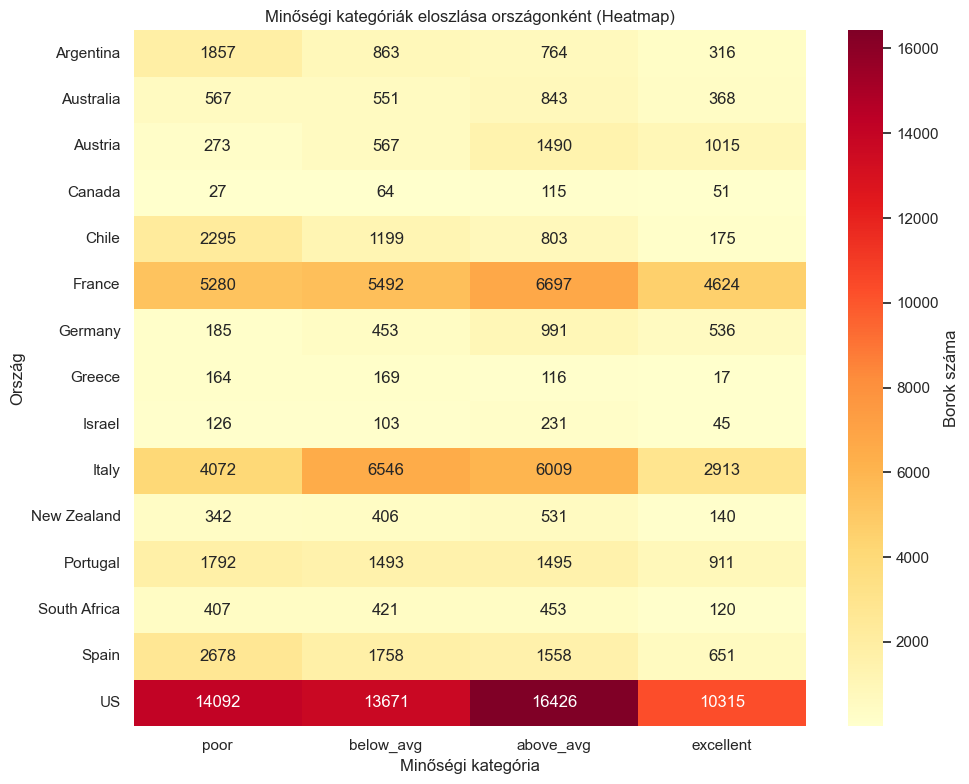

In [ ]:
# 9. Minőségi eloszlás részletesebben - Heatmap
# Ország vs. Minőségi kategória heatmap formátumban

# Csak a gyakori országok
top_countries = df_filtered_country['country'].value_counts().head(15).index
df_heatmap = df_filtered_country[df_filtered_country['country'].isin(top_countries)]

# Kereszttábla
heatmap_data = pd.crosstab(df_heatmap['country'], df_heatmap['group'])

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Borok száma'})
plt.title('Minőségi kategóriák eloszlása országonként (Heatmap)')
plt.ylabel('Ország')
plt.xlabel('Minőségi kategória')
plt.tight_layout()
plt.show()

C:\Users\2314l\AppData\Local\Temp\ipykernel_13464\3005863512.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=combo_avg.index, x=combo_avg.values, palette="rocket", orient='h')


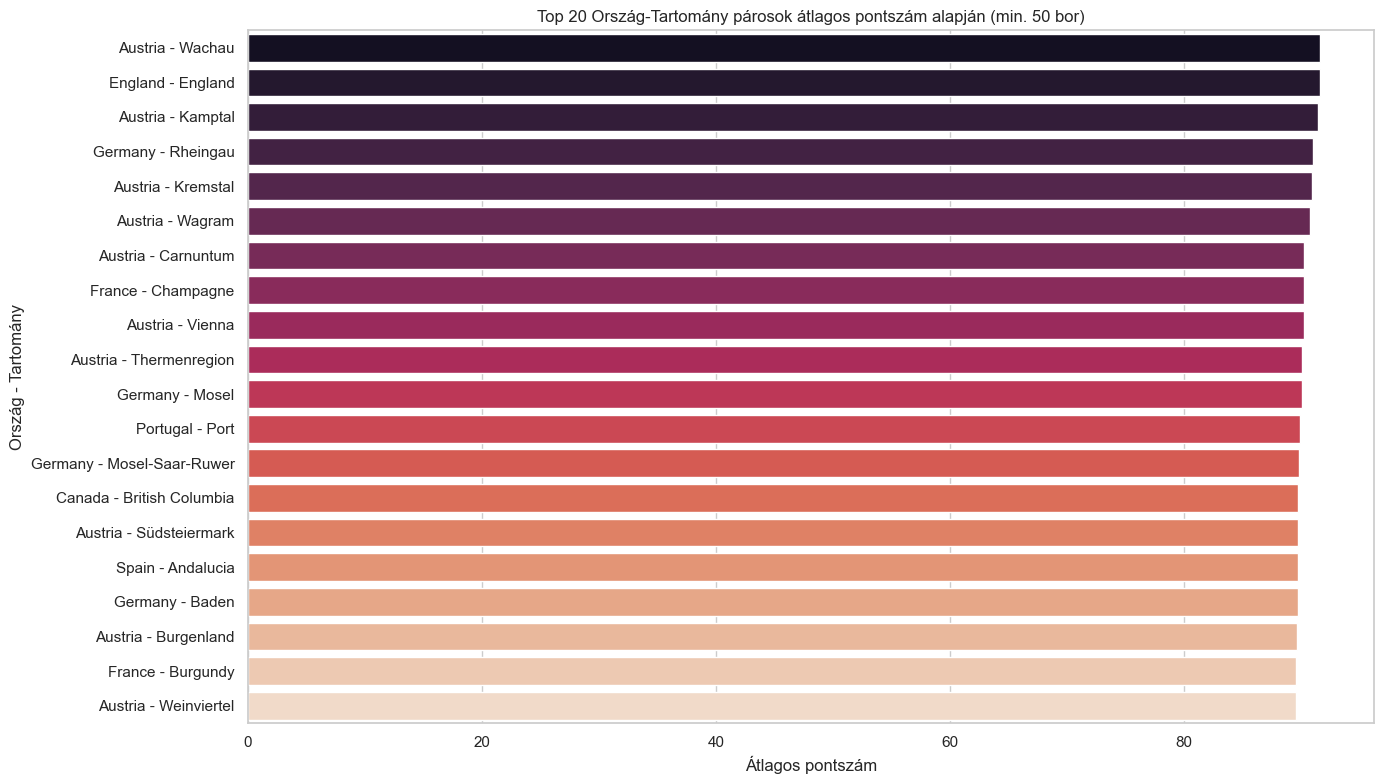

In [ ]:
# 8. Kombinált terület elemzés: Ország + Tartomány
# Mely ország-tartomány párosok a legjobbak?

# Kombinált oszlop létrehozása
df_categorized['country_province'] = df_categorized['country'] + ' - ' + df_categorized['province']

# Szűrés: csak ahol legalább 50 bor van
combo_counts = df_categorized['country_province'].value_counts()
valid_combos = combo_counts[combo_counts >= 50].index
df_combo = df_categorized[df_categorized['country_province'].isin(valid_combos)]

combo_avg = df_combo.groupby('country_province')['points'].mean().sort_values(ascending=False).head(20)

plt.figure(figsize=(14, 8))
sns.barplot(y=combo_avg.index, x=combo_avg.values, palette="rocket", orient='h')
plt.title('Top 20 Ország-Tartomány párosok átlagos pontszám alapján (min. 50 bor)')
plt.xlabel('Átlagos pontszám')
plt.ylabel('Ország - Tartomány')
plt.tight_layout()
plt.show()

Egyedi region_1 értékek száma: 1230
Hiányzó region_1 értékek: 0


C:\Users\2314l\AppData\Local\Temp\ipykernel_13464\1861745972.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_avg.index, y=region_avg.values, palette="magma")


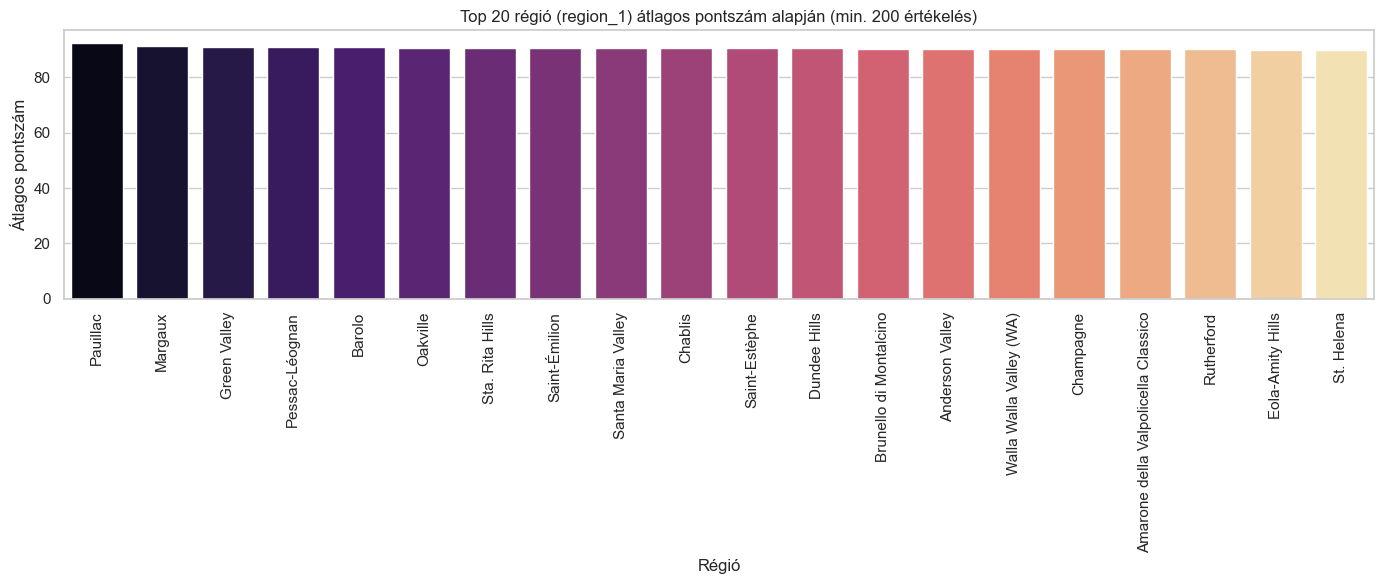

In [ ]:
# 7. Régiók (region_1) elemzése
# A region_1 finomabb granularitást ad, mint a province

# Kombinált oszlop létrehozása a megjelenítéshez: Ország - Régió
df_categorized['country_region'] = df_categorized['country'] + ' - ' + df_categorized['region_1']

# Megnézzük, hány egyedi régió van
print(f"Egyedi region_1 értékek száma: {df_categorized['region_1'].nunique()}")
print(f"Hiányzó region_1 értékek: {df_categorized['region_1'].isna().sum()}")

# Top régiók, ahol van elég adat
region_counts = df_categorized['country_region'].value_counts()
top_regions = region_counts[region_counts > 200].index
df_top_regions = df_categorized[df_categorized['country_region'].isin(top_regions)]

region_avg = df_top_regions.groupby('country_region')['points'].mean().sort_values(ascending=False).head(20)

plt.figure(figsize=(14, 8))
sns.barplot(x=region_avg.index, y=region_avg.values, palette="magma")
plt.xticks(rotation=90)
plt.title('Top 20 régió (region_1) átlagos pontszám alapján (min. 200 értékelés)')
plt.ylabel('Átlagos pontszám')
plt.xlabel('Ország - Régió')
plt.tight_layout()
plt.show()

C:\Users\2314l\AppData\Local\Temp\ipykernel_13464\3226429364.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=province_stats.head(15).index, y=province_stats.head(15)['mean'],
C:\Users\2314l\AppData\Local\Temp\ipykernel_13464\3226429364.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90)
C:\Users\2314l\AppData\Local\Temp\ipykernel_13464\3226429364.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=province_stats_sorted.head(15).index, y=province_stats_sorted.head(15)['std'],
C:\Users\2314l\AppData\Local\Temp\ipykernel_13464\322642936

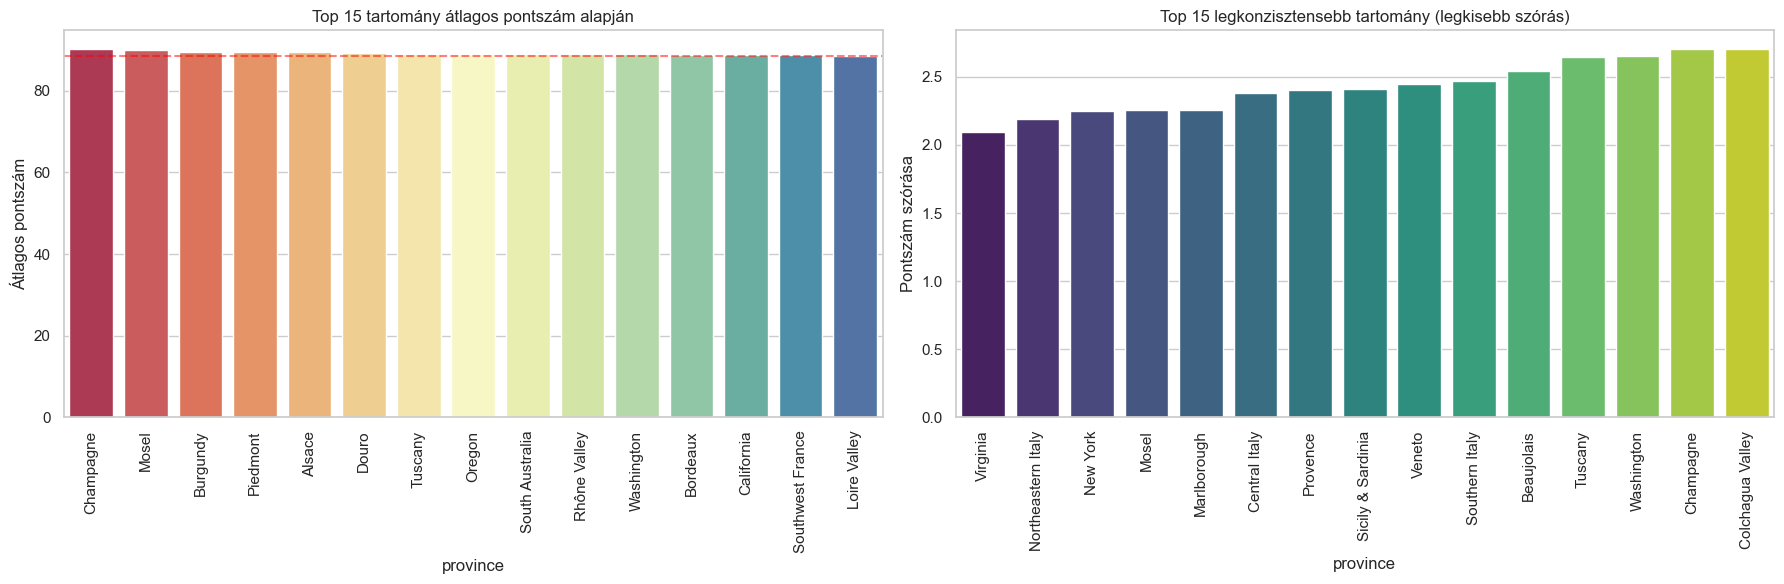

Top 10 tartomány átlag és konzisztencia alapján:


,mean,std,count
province,,,
Champagne,90.234966,2.702121,1613
Mosel,90.049086,2.255479,1039
Burgundy,89.569347,3.110104,3980
Piedmont,89.536873,2.822597,3729
Alsace,89.372131,2.965298,2440
Douro,89.126464,2.871399,1281
Tuscany,89.074614,2.644699,5897
Oregon,89.051926,2.802526,5373
South Australia,89.037806,2.894161,1349


In [ ]:
# 6. Tartomány (Province) részletes elemzése - átlagok és konzisztencia
# Mely tartományok termelnek konzisztensen jó borokat?

top_provinces = df_categorized['province'].value_counts().head(30).index
df_top_provinces = df_categorized[df_categorized['province'].isin(top_provinces)]

province_stats = df_top_provinces.groupby('province')['points'].agg(['mean', 'std', 'count']).sort_values(by='mean', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Átlagos pontszám tartományonként
sns.barplot(x=province_stats.head(15).index, y=province_stats.head(15)['mean'], 
            ax=axes[0], palette="Spectral")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90)
axes[0].set_title('Top 15 tartomány átlagos pontszám alapján')
axes[0].set_ylabel('Átlagos pontszám')
axes[0].axhline(y=df_categorized['points'].mean(), color='red', linestyle='--', alpha=0.5)

# Szórás (konzisztencia) - minél kisebb, annál kiszámíthatóbb a minőség
province_stats_sorted = province_stats.sort_values(by='std')
sns.barplot(x=province_stats_sorted.head(15).index, y=province_stats_sorted.head(15)['std'], 
            ax=axes[1], palette="viridis")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90)
axes[1].set_title('Top 15 legkonzisztensebb tartomány (legkisebb szórás)')
axes[1].set_ylabel('Pontszám szórása')

plt.tight_layout()
plt.show()

print("Top 10 tartomány átlag és konzisztencia alapján:")
display(province_stats.head(10))